In [1]:
import csv
import json
import librosa
import shutil
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from librosa.feature import melspectrogram

In [4]:
# Constants for Mel-Spectrogram preprocessing
LABEL_MAP = {
    "Accordion": 0,
    "AcousticGuitar": 1,
    "Banjo": 2,
    "BassGuitar": 3,
    "Clarinet": 4,
    "Cowbell": 5,
    "Cymbals": 6,
    "Dobro": 7,
    "DrumSet": 8,
    "ElectroGuitar": 9,
    "FloorTom": 10,
    "Flute": 11,
    "Harmonica": 12,
    "Harmonium": 13,
    "HiHats": 14,
    "Horn": 15,
    "Keyboard": 16,
    "Mandolin": 17,
    "Organ": 18,
    "Piano": 19,
    "Saxophone": 20,
    "Shakers": 21,
    "Tambourine": 22,
    "Trombone": 23,
    "Trumpet": 24,
    "Ukulele": 25,
    "Vibraphone": 26,
    "Violin": 27
}

SAMPLE_RATE = 16000
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 320

In [15]:
MEAN_DB = 0
STD_DB = 0

manifest_headers = ["Path", "Label", "Mel_Path"]
manifest_data = []

In [16]:
# Create the processed directory
processed_dir = Path("data/processed")
if processed_dir.exists():
    shutil.rmtree(processed_dir)

processed_dir.mkdir(parents=True, exist_ok=True)

total_sum = 0
total_sq_sum = 0
total_elements = 0
max_length = -np.inf
# Create the numpy files
for file in Path("data/raw").rglob("*.wav"):
    try:
        print(f"Processing: {file}")

        waveform, _ = librosa.load(file, sr=SAMPLE_RATE)
        mel_spectrogram = melspectrogram(y=waveform, sr=SAMPLE_RATE, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
        mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

        # Save numpy file
        label = str(file.parent.name).replace("_", " ")
        label = label.title()
        label = label.replace(" ", "")
        output_path = processed_dir / f"{label}_{file.stem}_mel.npy"
        np.save(output_path, mel_spectrogram_db)

        # Increment metrics
        total_sum += np.sum(mel_spectrogram_db)
        total_sq_sum += np.sum(mel_spectrogram_db ** 2)
        total_elements += mel_spectrogram_db.size

        if mel_spectrogram.shape[1] > max_length:
            max_length = mel_spectrogram.shape[1]

        # Save data to the manifest
        manifest_data.append([file, label, output_path])

    except Exception as e:
        print(f"Error processing {file}: {e}")


Processing: data\raw\music_dataset\Accordion\100.wav
Processing: data\raw\music_dataset\Accordion\1000.wav
Processing: data\raw\music_dataset\Accordion\1001.wav
Processing: data\raw\music_dataset\Accordion\1002.wav
Processing: data\raw\music_dataset\Accordion\1003.wav
Processing: data\raw\music_dataset\Accordion\1004.wav
Processing: data\raw\music_dataset\Accordion\1005.wav
Processing: data\raw\music_dataset\Accordion\1006.wav
Processing: data\raw\music_dataset\Accordion\1007.wav
Processing: data\raw\music_dataset\Accordion\1008.wav
Processing: data\raw\music_dataset\Accordion\1009.wav
Processing: data\raw\music_dataset\Accordion\101.wav
Processing: data\raw\music_dataset\Accordion\1010.wav
Processing: data\raw\music_dataset\Accordion\1011.wav
Processing: data\raw\music_dataset\Accordion\1012.wav
Processing: data\raw\music_dataset\Accordion\1013.wav
Processing: data\raw\music_dataset\Accordion\1014.wav
Processing: data\raw\music_dataset\Accordion\1015.wav
Processing: data\raw\music_dat

In [17]:
MEAN_DB = total_sum / total_elements
STD_DB = np.sqrt((total_sq_sum / total_elements) - (MEAN_DB ** 2))
MAX_MLEN = max_length

print(f"MEAN_DB: {MEAN_DB:.3f}")
print(f"STD_DB: {STD_DB:.3f}")
print(f"MAX_MLEN: {MAX_MLEN:.3f}")

MEAN_DB: -49.982
STD_DB: 18.420


In [22]:
metadata_dir = processed_dir / "metadata"
if metadata_dir.exists():
    shutil.rmtree(metadata_dir)

metadata_dir.mkdir(parents=True, exist_ok=True)

mel_params = {
    "LABEL_MAP": LABEL_MAP,
    "SAMPLE_RATE": SAMPLE_RATE,
    "N_MELS": N_MELS,
    "N_FFT": N_FFT,
    "HOP_LENGTH": HOP_LENGTH,
    "MEAN_DB": float(MEAN_DB),
    "STD_DB": float(STD_DB),
    "MAX_MLEN": MAX_MLEN,
}

with open(metadata_dir / "mel_params.json", "w") as f:
    json.dump(mel_params, f)

In [23]:
with open(metadata_dir / "manifest.csv", "w", newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(manifest_headers)
    writer.writerows(manifest_data)

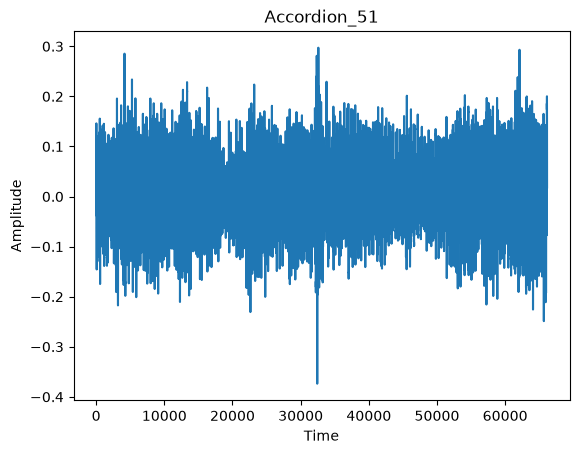

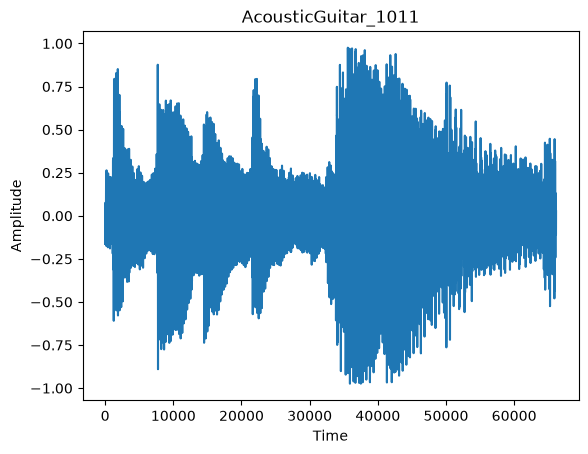

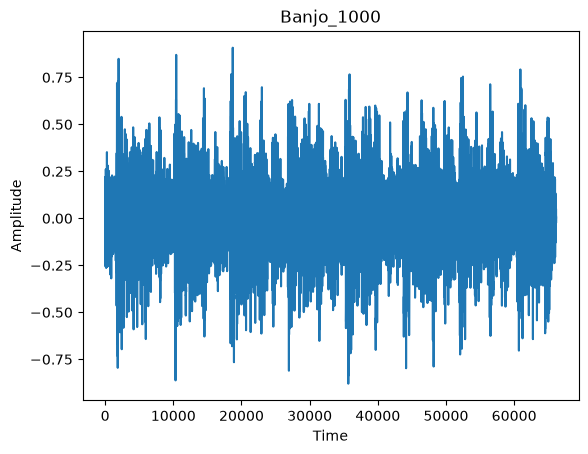

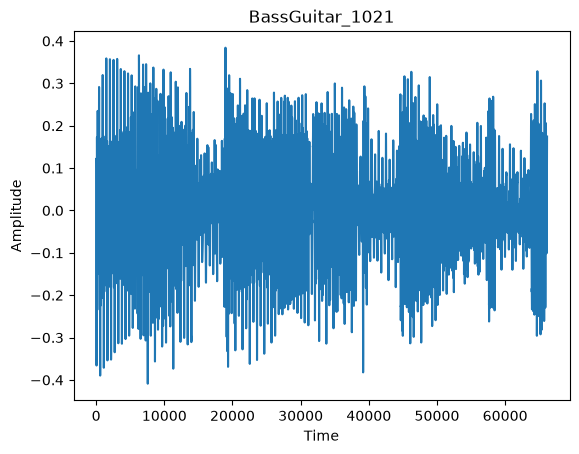

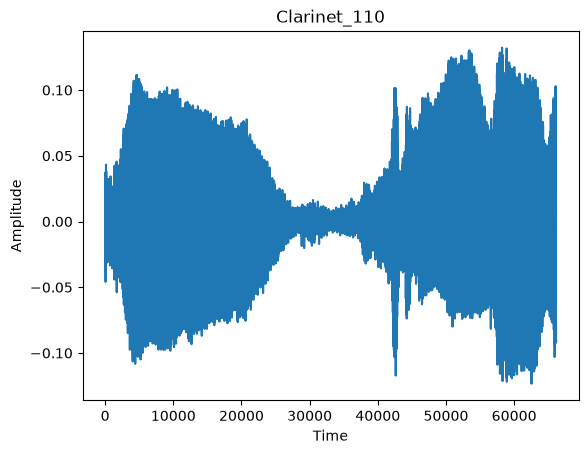

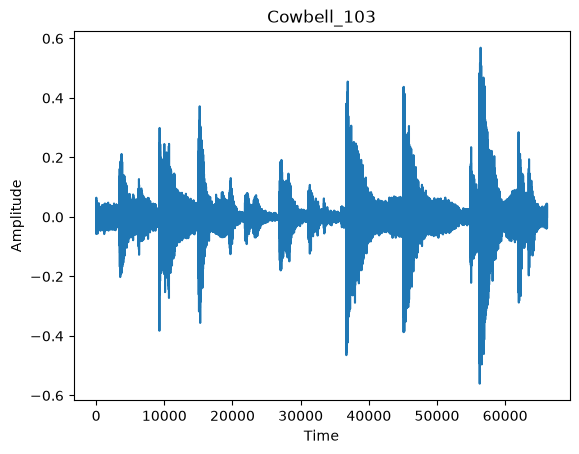

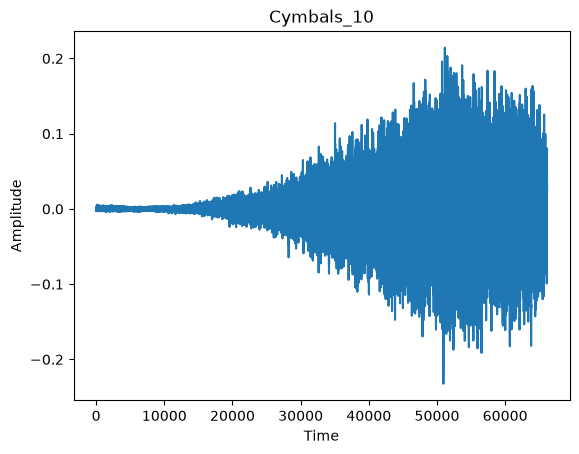

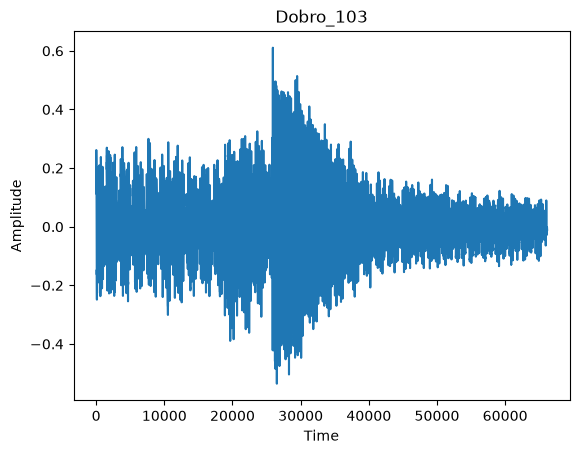

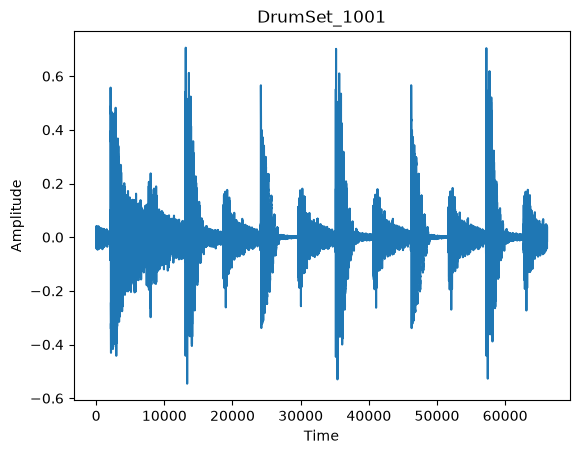

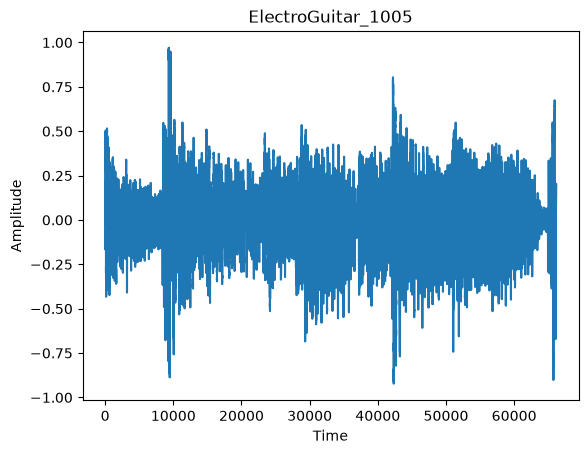

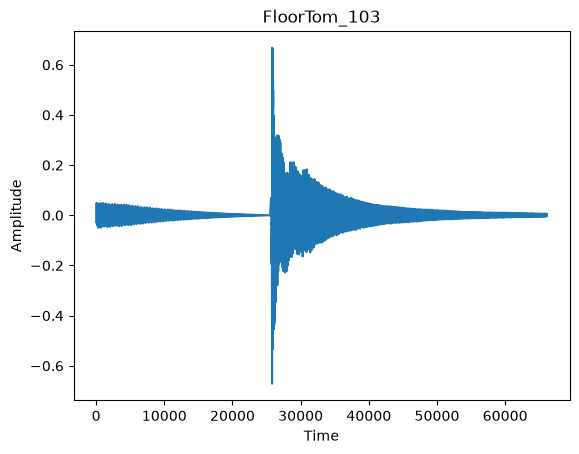

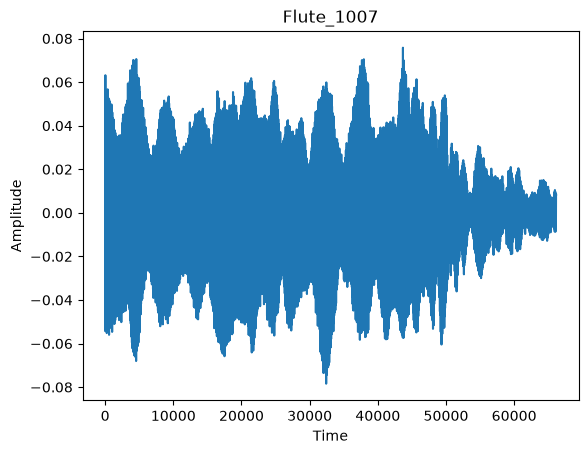

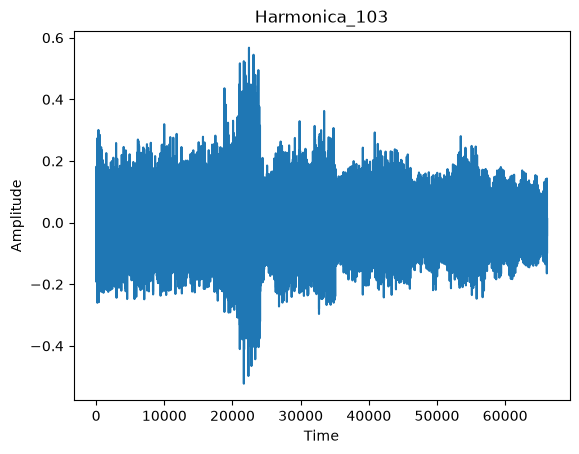

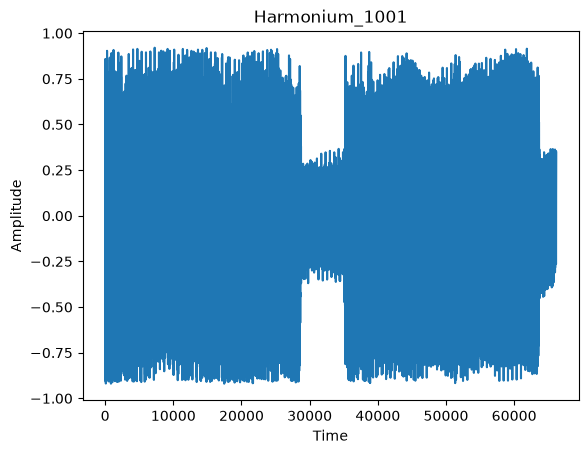

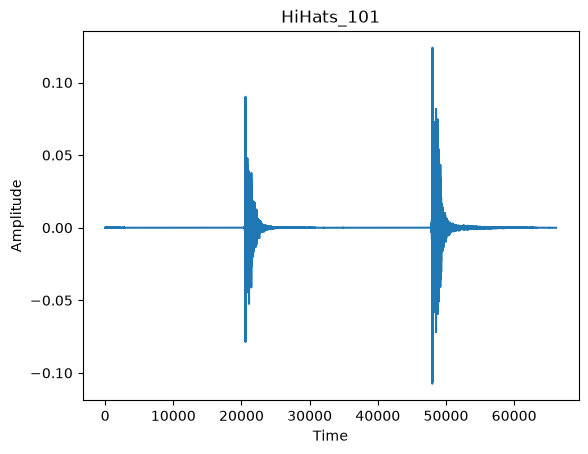

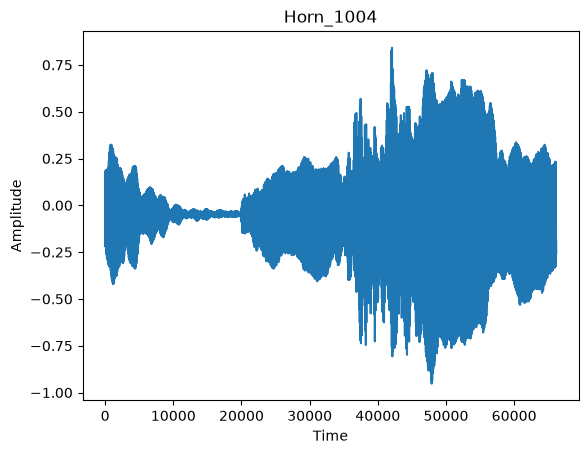

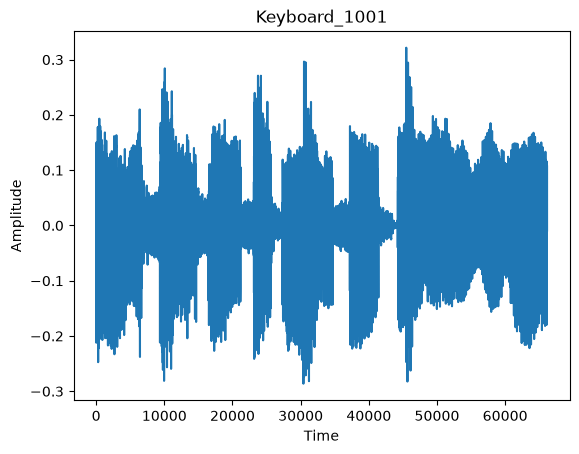

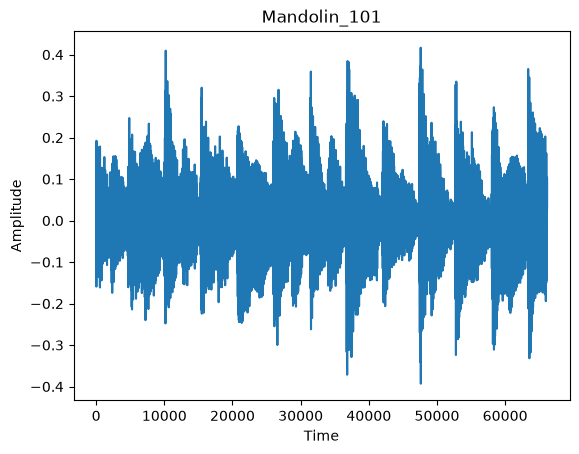

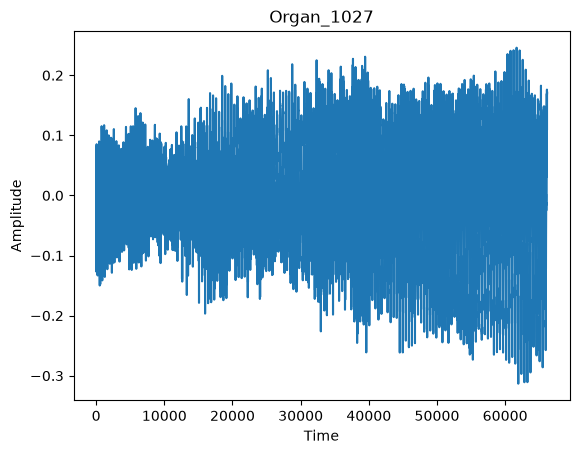

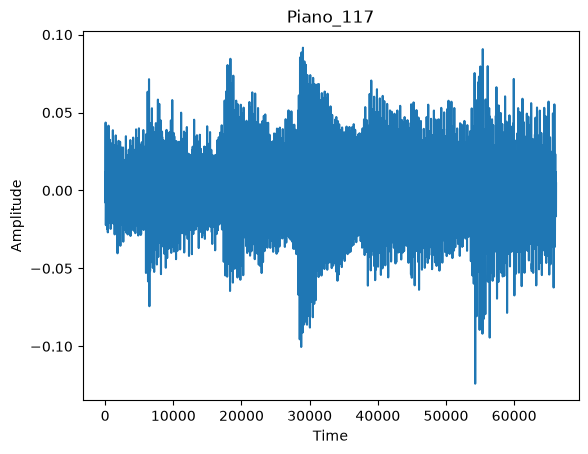

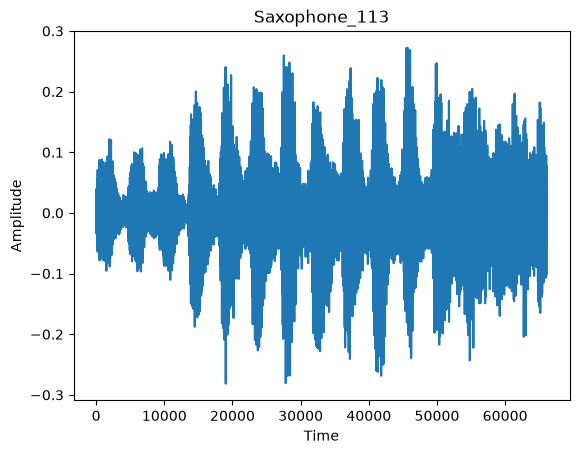

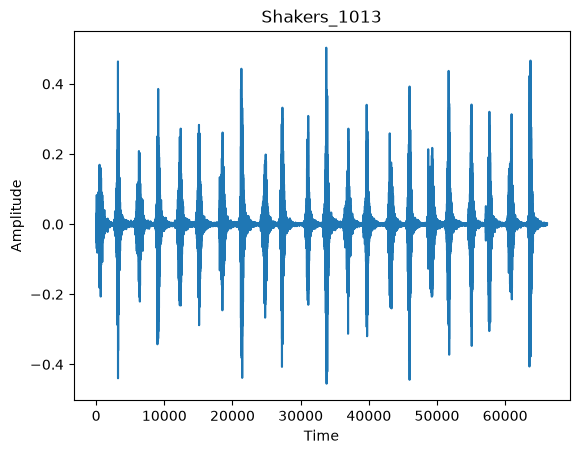

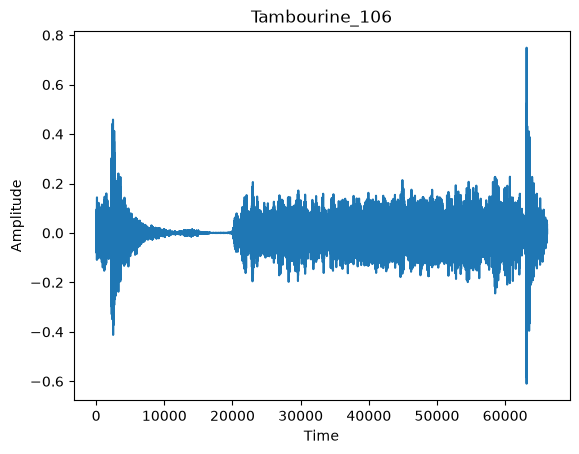

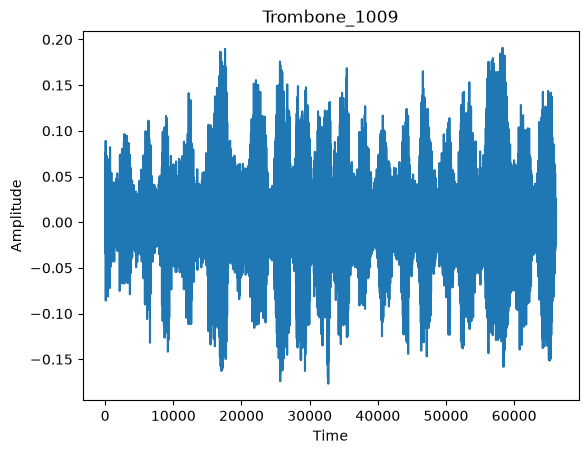

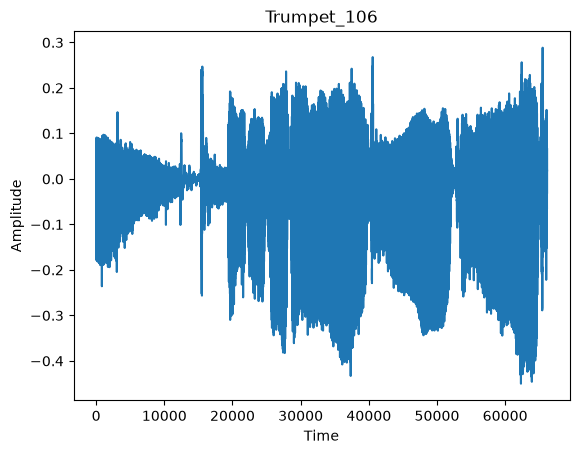

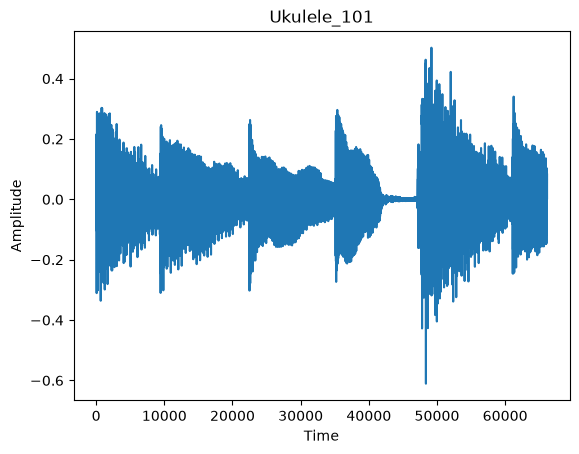

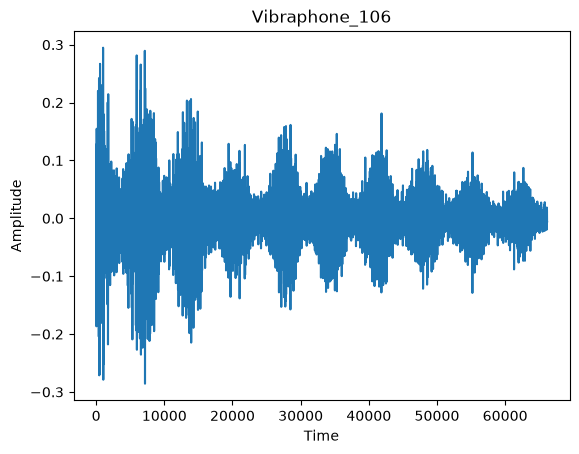

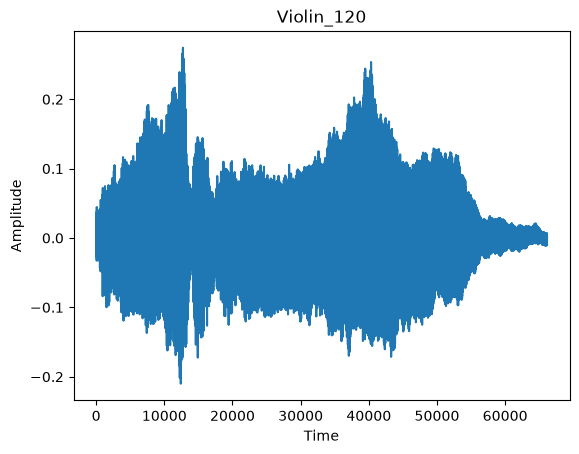

In [22]:
# Visualize Mel Spectrograms
wave_paths = {
    "Accordion": "data\\raw\\music_dataset\\Accordion\\51.wav",
    "AcousticGuitar": "data\\raw\\music_dataset\\Acoustic_Guitar\\1011.wav",
    "Banjo": "data\\raw\\music_dataset\\Banjo\\1000.wav",
    "BassGuitar": "data\\raw\\music_dataset\\Bass_Guitar\\1021.wav",
    "Clarinet": "data\\raw\\music_dataset\\Clarinet\\110.wav",
    "Cowbell": "data\\raw\\music_dataset\\cowbell\\103.wav",
    "Cymbals": "data\\raw\\music_dataset\\Cymbals\\10.wav",
    "Dobro": "data\\raw\\music_dataset\\Dobro\\103.wav",
    "DrumSet": "data\\raw\\music_dataset\\Drum_set\\1001.wav",
    "ElectroGuitar": "data\\raw\\music_dataset\\Electro_Guitar\\1005.wav",
    "FloorTom": "data\\raw\\music_dataset\\Floor_Tom\\103.wav",
    "Flute": "data\\raw\\music_dataset\\flute\\1007.wav",
    "Harmonica": "data\\raw\\music_dataset\\Harmonica\\103.wav",
    "Harmonium": "data\\raw\\music_dataset\\Harmonium\\1001.wav",
    "HiHats": "data\\raw\\music_dataset\\Hi_Hats\\101.wav",
    "Horn": "data\\raw\\music_dataset\\Horn\\1004.wav",
    "Keyboard": "data\\raw\\music_dataset\\Keyboard\\1001.wav",
    "Mandolin": "data\\raw\\music_dataset\\Mandolin\\101.wav",
    "Organ": "data\\raw\\music_dataset\\Organ\\1027.wav",
    "Piano": "data\\raw\\music_dataset\\Piano\\117.wav",
    "Saxophone": "data\\raw\\music_dataset\\Saxophone\\113.wav",
    "Shakers": "data\\raw\\music_dataset\\Shakers\\1013.wav",
    "Tambourine": "data\\raw\\music_dataset\\Tambourine\\106.wav",
    "Trombone": "data\\raw\\music_dataset\\Trombone\\1009.wav",
    "Trumpet": "data\\raw\\music_dataset\\Trumpet\\106.wav",
    "Ukulele": "data\\raw\\music_dataset\\Ukulele\\101.wav",
    "Vibraphone": "data\\raw\\music_dataset\\vibraphone\\106.wav",
    "Violin": "data\\raw\\music_dataset\\Violin\\120.wav",
}

for instrument in wave_paths:
    y, sr = librosa.load(wave_paths[instrument])

    name = instrument + "_" + str(Path(wave_paths[instrument]).stem)

    plt.plot(y)
    plt.title(name)
    plt.savefig("images/wav/" + name + ".png", dpi=300)
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.show()


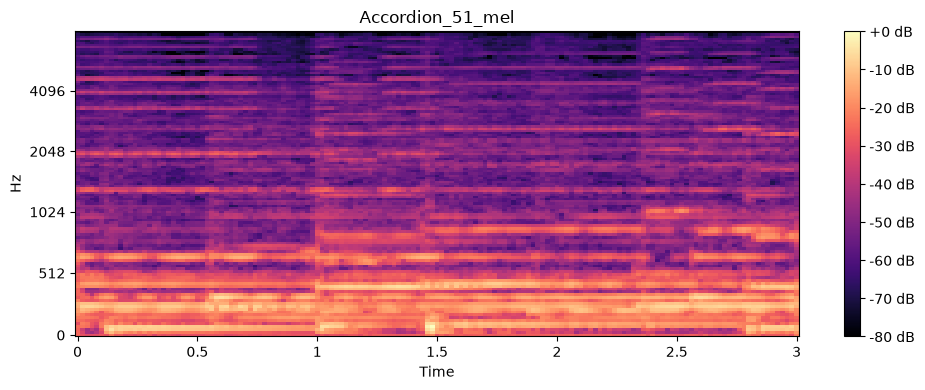

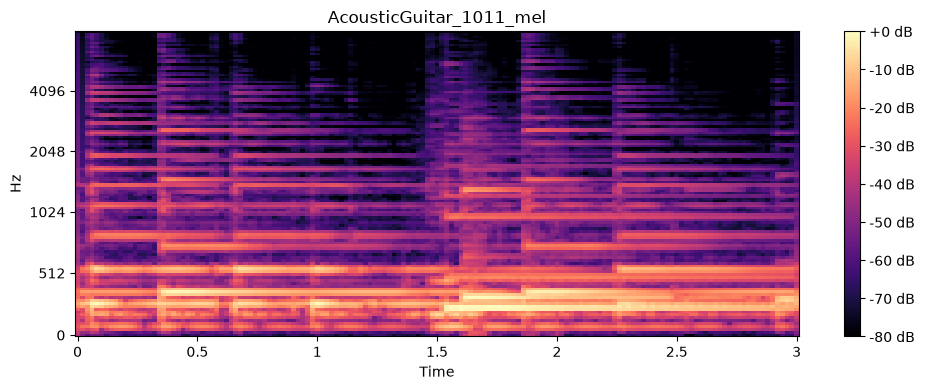

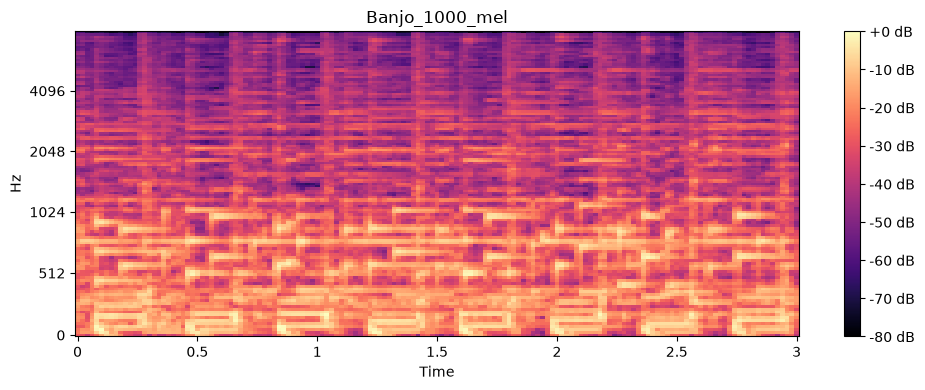

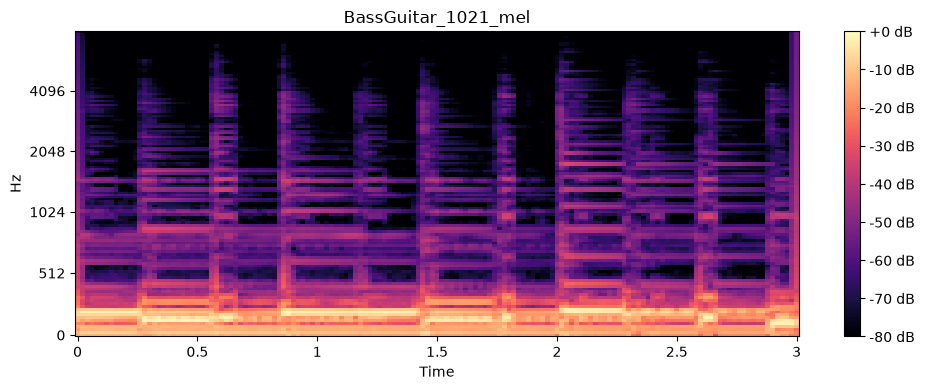

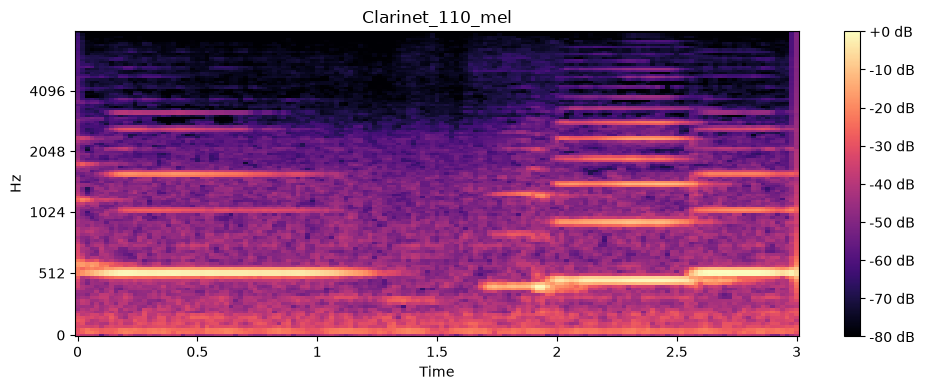

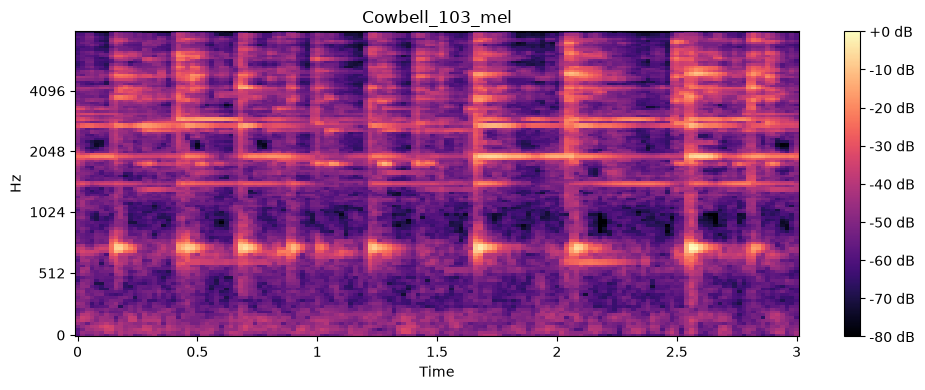

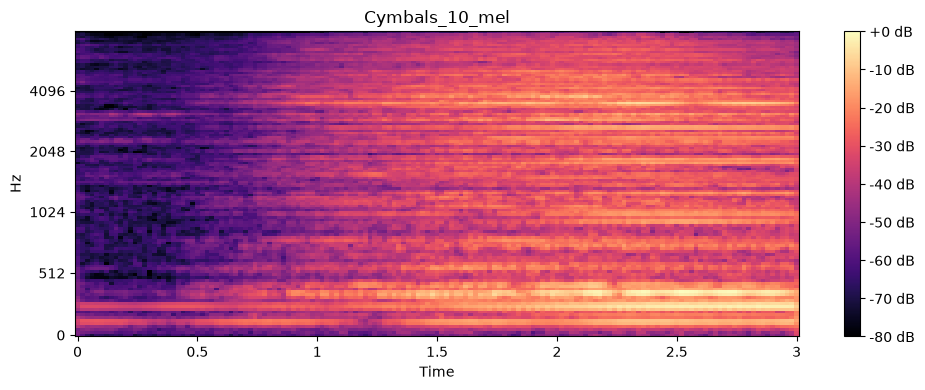

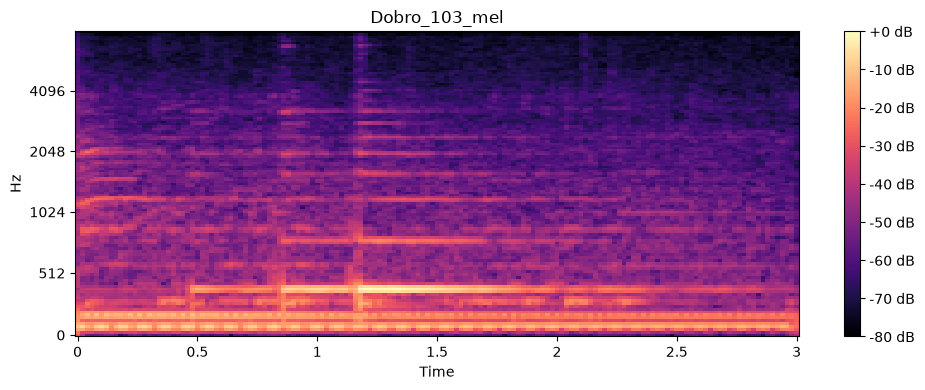

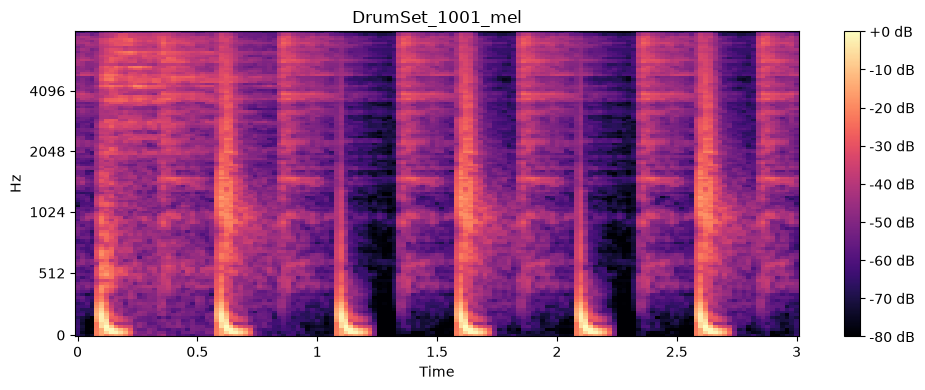

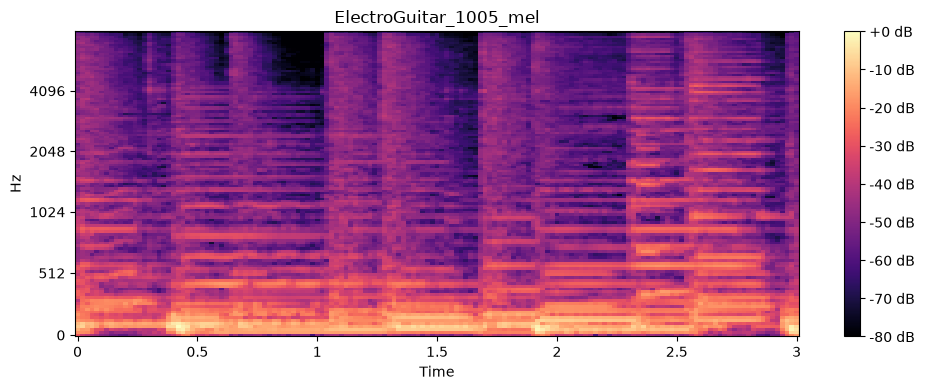

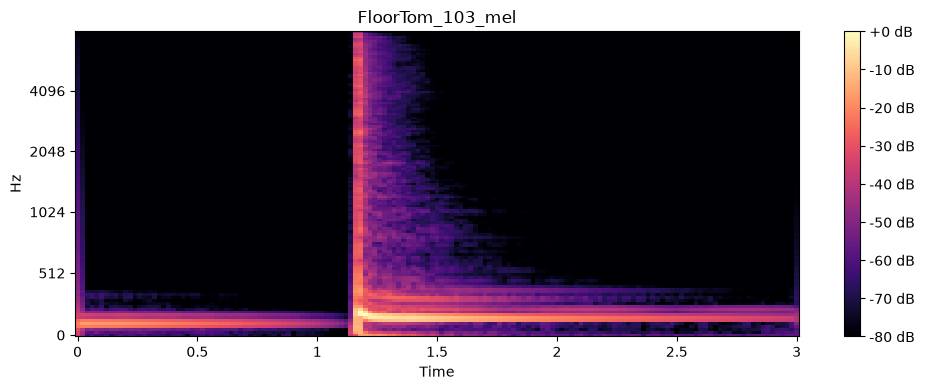

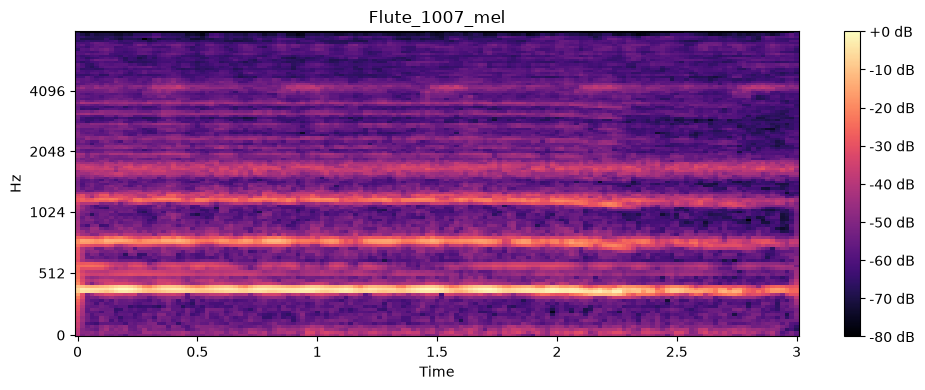

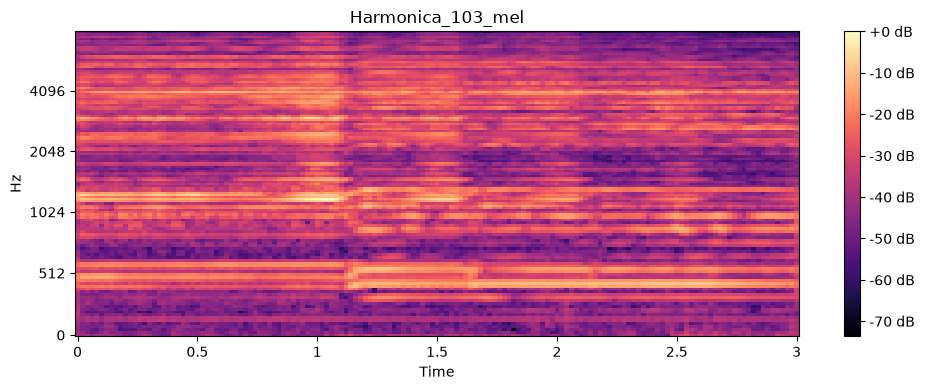

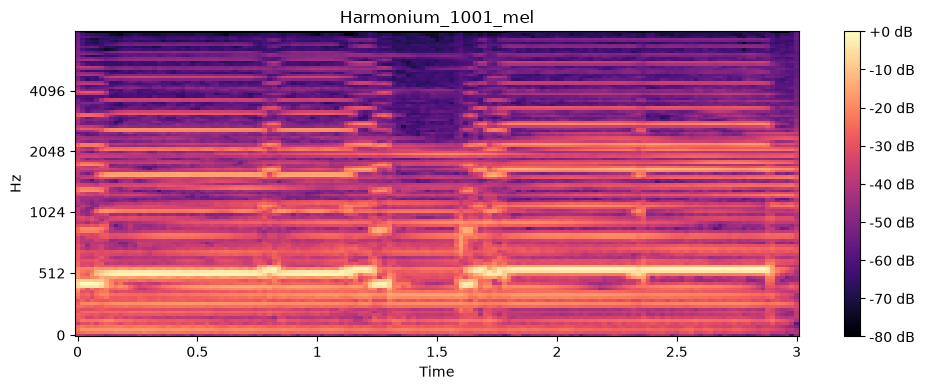

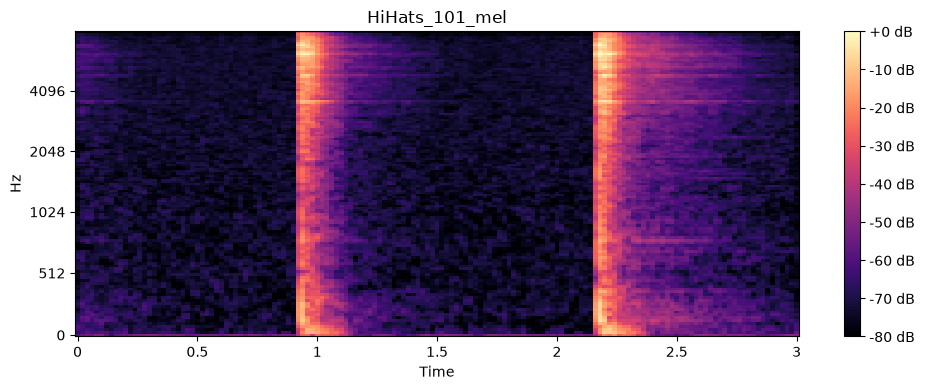

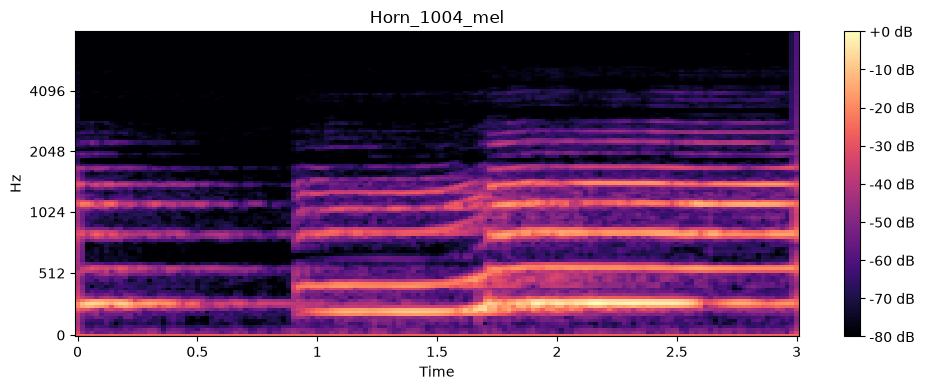

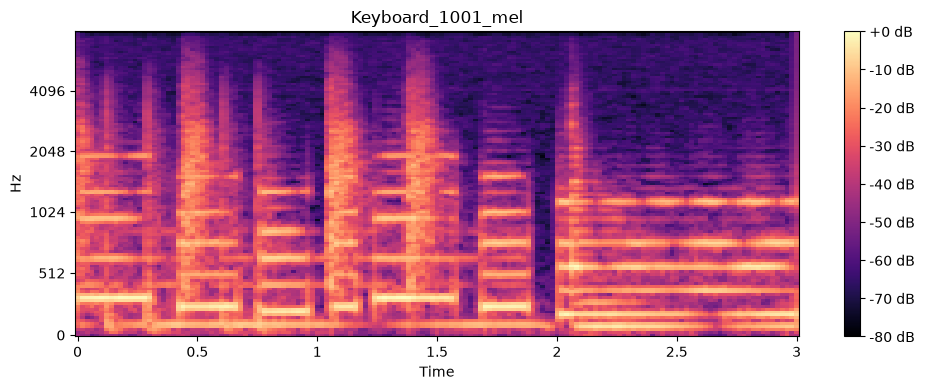

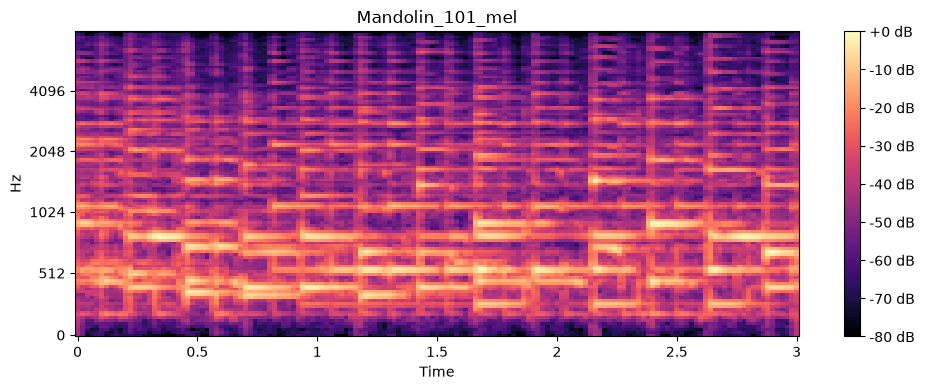

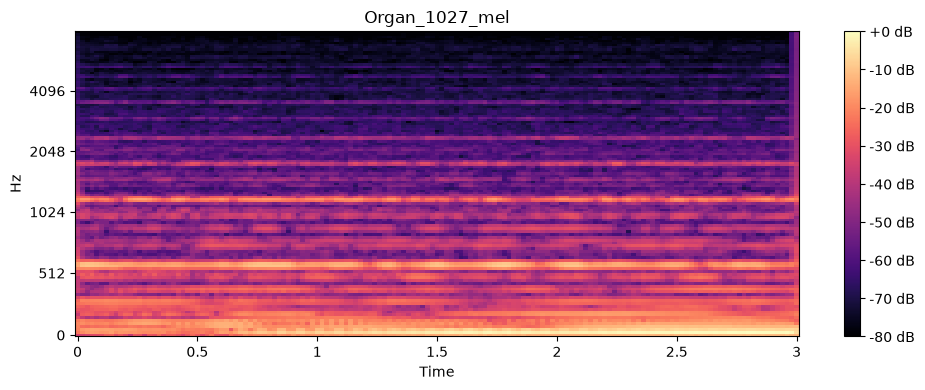

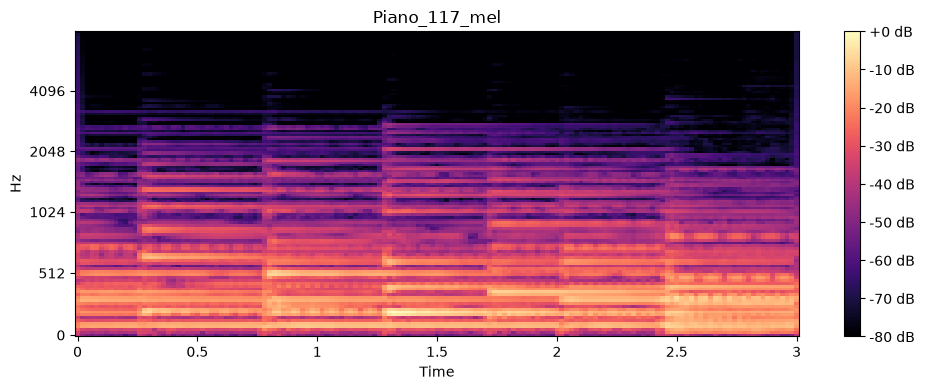

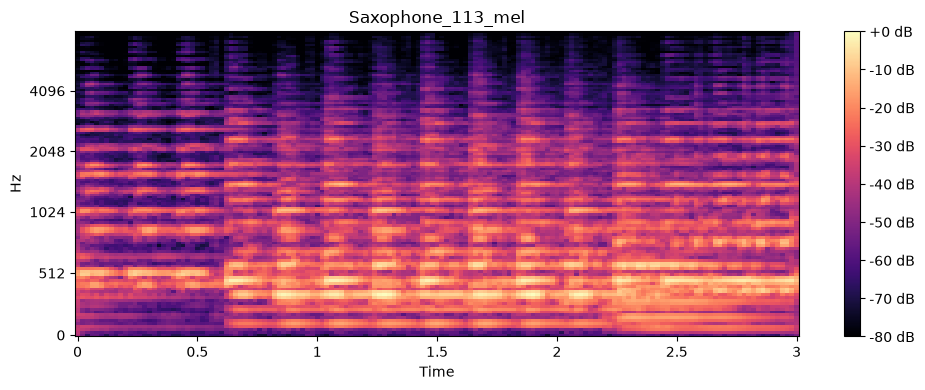

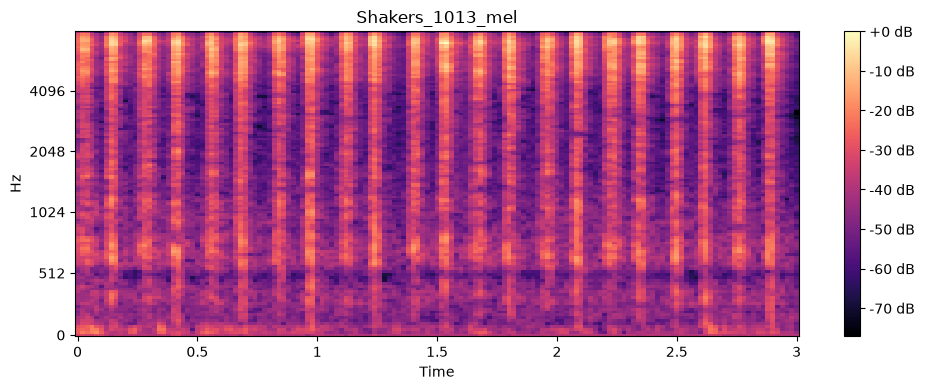

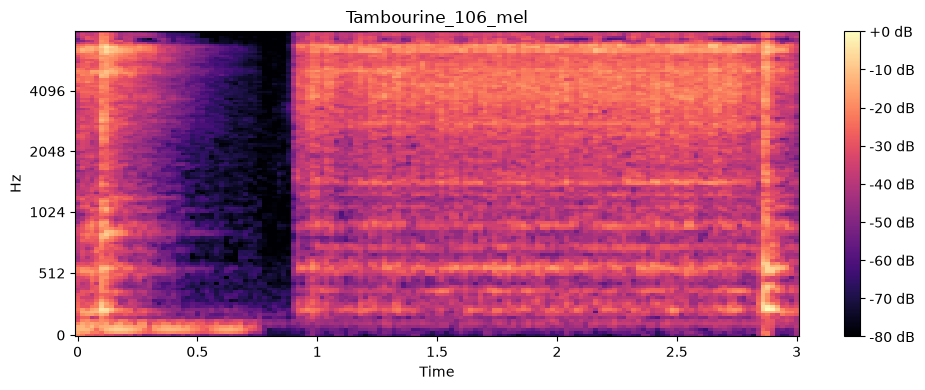

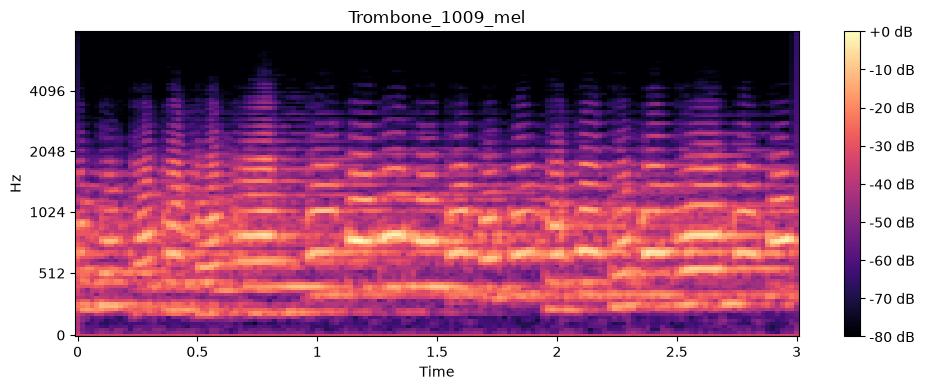

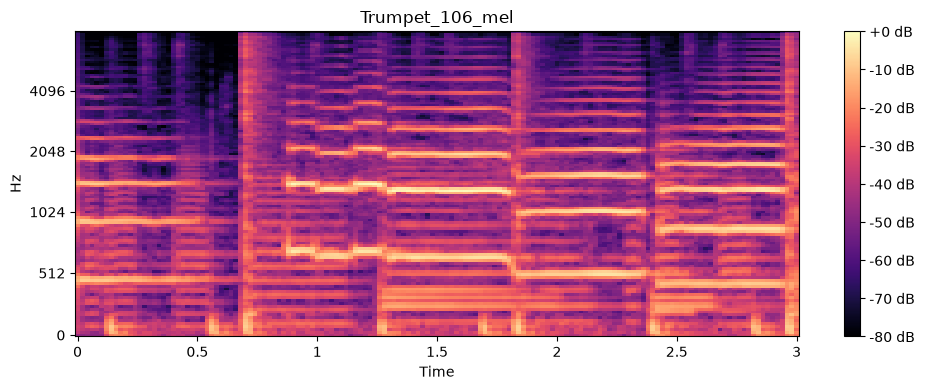

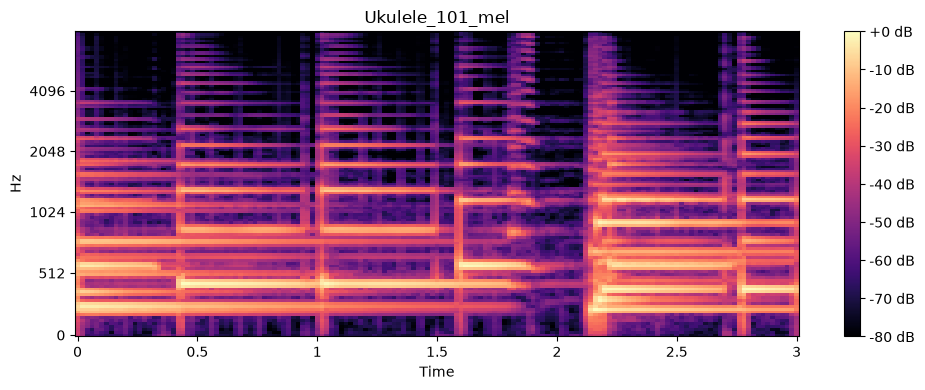

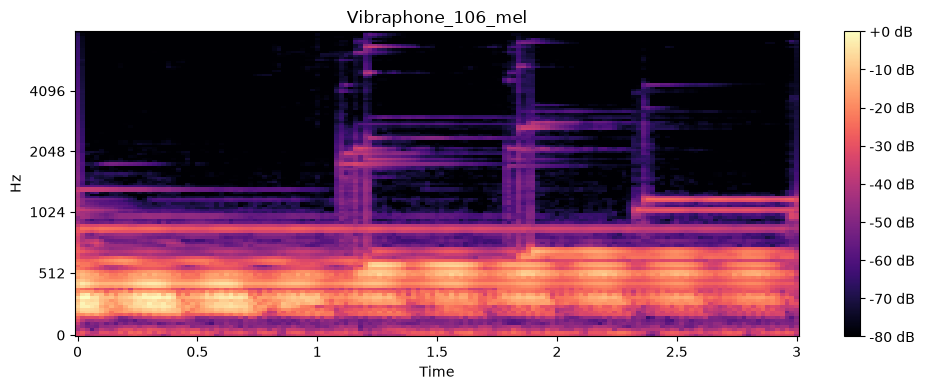

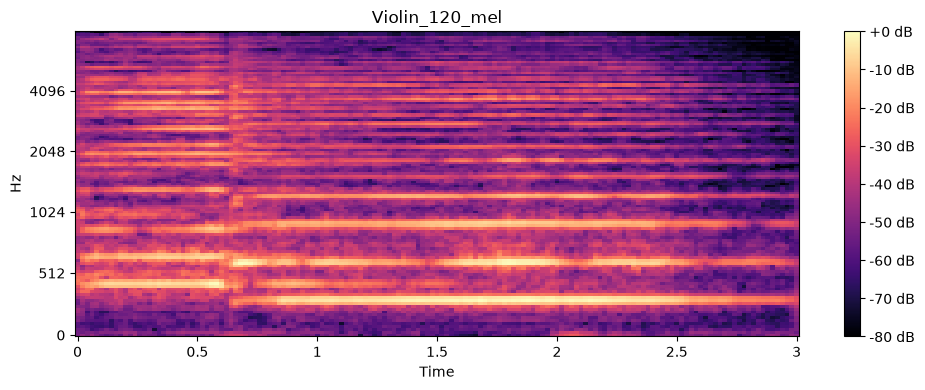

In [23]:
# Visualize Mel Spectrograms
npy_paths = {
    "Accordion": "data\\processed\\test\\Accordion_51_mel.npy",
    "AcousticGuitar": "data\\processed\\test\\AcousticGuitar_1011_mel.npy",
    "Banjo": "data\\processed\\test\\Banjo_1000_mel.npy",
    "BassGuitar": "data\\processed\\test\\BassGuitar_1021_mel.npy",
    "Clarinet": "data\\processed\\test\\Clarinet_110_mel.npy",
    "Cowbell": "data\\processed\\test\\Cowbell_103_mel.npy",
    "Cymbals": "data\\processed\\test\\Cymbals_10_mel.npy",
    "Dobro": "data\\processed\\test\\Dobro_103_mel.npy",
    "DrumSet": "data\\processed\\test\\DrumSet_1001_mel.npy",
    "ElectroGuitar": "data\\processed\\test\\ElectroGuitar_1005_mel.npy",
    "FloorTom": "data\\processed\\test\\FloorTom_103_mel.npy",
    "Flute": "data\\processed\\test\\Flute_1007_mel.npy",
    "Harmonica": "data\\processed\\test\\Harmonica_103_mel.npy",
    "Harmonium": "data\\processed\\test\\Harmonium_1001_mel.npy",
    "HiHats": "data\\processed\\test\\HiHats_101_mel.npy",
    "Horn": "data\\processed\\test\\Horn_1004_mel.npy",
    "Keyboard": "data\\processed\\test\\Keyboard_1001_mel.npy",
    "Mandolin": "data\\processed\\test\\Mandolin_101_mel.npy",
    "Organ": "data\\processed\\test\\Organ_1027_mel.npy",
    "Piano": "data\\processed\\test\\Piano_117_mel.npy",
    "Saxophone": "data\\processed\\test\\Saxophone_113_mel.npy",
    "Shakers": "data\\processed\\test\\Shakers_1013_mel.npy",
    "Tambourine": "data\\processed\\test\\Tambourine_106_mel.npy",
    "Trombone": "data\\processed\\test\\Trombone_1009_mel.npy",
    "Trumpet": "data\\processed\\test\\Trumpet_106_mel.npy",
    "Ukulele": "data\\processed\\test\\Ukulele_101_mel.npy",
    "Vibraphone": "data\\processed\\test\\Vibraphone_106_mel.npy",
    "Violin": "data\\processed\\test\\Violin_120_mel.npy",
}

for instrument in npy_paths:
    mel_spectrogram = np.load(npy_paths[instrument])

    plt.figure(figsize=(10, 4))
    fig = librosa.display.specshow(
        mel_spectrogram,
        sr=SAMPLE_RATE,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="mel",
    )

    name = str(Path(npy_paths[instrument]).stem)

    plt.colorbar(fig, format='%+2.0f dB')
    plt.title(name)
    plt.tight_layout()
    plt.savefig("images/mels/" + name + ".png", dpi=300)
    plt.show()